# 23: the second-order image, the stochastic tier

The second-order image (`dtfit.stochastic.SecondOrderImage`) collects a
series' autocovariance, spectrum, aggregated variance and trend/cycle sums
into one additive statistic, exact under merge. Every estimator, gate and
forecaster of the tier reads from it. Claims:

1. The image is a sufficient statistic for the tier's read-outs: a record
   imaged whole and imaged in blocks then merged agree, at a matched scale
   budget. False if a pinned-budget merge disagrees with the whole record
   beyond floating-point noise.
2. Each of the tier's own functionals recovers the process parameter it
   targets, with its mean error stated beside the foreign, non-dtfit
   estimator of the same quantity and read as whatever it is: parity where
   the two agree, a win or a loss where they do not. False if a route's
   mean error sits outside the band the reading states for it.
3. The regime router (`fit_stochastic`) identifies which of seven process
   classes generated a series at least as well as a classical twin built
   from the same gates with textbook estimators. False if dtfit's overall
   accuracy is not at least the classical twin's, or if any one class falls
   far below the rest.
4. On structured (non-white-noise) processes the router's forecast is at
   parity with the classical twin on a mean-reverting process and clearly
   ahead of the random walk on a trend+cycle process; it is not claimed
   ahead everywhere. False if any ratio is not finite, if the merged and
   classical ratios diverge on the mean-reverting case, or if the
   trend+cycle process is not a clear win.
5. A finite-order AR process never reads as long memory, and a genuinely
   long-memory one does; fractionally differencing a long-memory series at
   its own estimated `d` removes the memory. False if an AR series reads
   long memory, an ARFIMA series does not, or the differenced series still
   carries visible long memory.
6. The streaming filter (`StochasticFilter`) tracks persistence online,
   flags a persistence jump and a volatility switch with a latency of a few
   dozen samples, flags a white-noise stream rarely, and holds state under a
   fixed cap however long the stream runs and however many flags it
   trips. False if tracking is far off, a
   break goes undetected, white noise is flagged often, or the state grows
   past that cap.
7. `StochasticModel.simulate` round-trips: fitting a simulated realization
   of a detected regime recovers that regime, and Student-t innovations
   produce visibly fatter tails than Gaussian ones at the same variance.
   False if a round trip lands on a different regime more than
   occasionally, or if the two innovation distributions are not
   distinguishable by their kurtosis.
8. The router has known, named limits: the cycle gate's effect-size floor
   alone is calibrated for white noise but not for autocorrelated noise,
   and two of its constants are hand-set rather than derived. This section
   has no falsifier; it is a report of what does not work, not a claim.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

from dtfit.stochastic import (
    SecondOrderImage, SecondOrderStream, StochasticFilter,
    ar1_reversion, ar_order, cycle_period, decompose_trend_cycle,
    fit_stochastic, fractional_difference, garch_persistence,
    hurst_aggvar, hurst_spectral,
)
from dtfit_experimental.study import notebook
from dtfit_experimental.study.baselines import hurst_dfa, hurst_rs
from dtfit_experimental.study.classical_stochastic import (
    classical_decompose, fit_classical_stochastic, garch_mle_persistence,
    ols_ar1, periodogram_period,
)
from dtfit_experimental.study.metrics import metrics
from dtfit_experimental.study.processes import (
    ROUTER_CASES, forecast_skill, gen_ar1, gen_ar2_cycle, gen_arfima,
    gen_arp, gen_garch, gen_trend_cycle, regime_matches, suite_horizon,
)

# statsmodels emits noisy future-API warnings on adfuller/acorr_lm/ARIMA
# that carry no information for this notebook's reading.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

SEEDS = 2 if QUICK else 8
CALIB_DRAWS = 40 if QUICK else 200
IMAGE_N = 100_000 if QUICK else 1_000_000
print(f"QUICK={QUICK} SEEDS={SEEDS} CALIB_DRAWS={CALIB_DRAWS} IMAGE_N={IMAGE_N}")


QUICK=False SEEDS=8 CALIB_DRAWS=200 IMAGE_N=1000000


## 1. The image is the sufficient statistic

An AR(1) record of `IMAGE_N` samples, imaged whole
(`SecondOrderImage.of`) and imaged through `SecondOrderStream`, the
shipping block form, in two ways: at its own default scale budget (a
fixed `scales=10`, smaller than the whole record's default) and pinned to
the whole record's own budget. A third stream forces the fold-to-coarse
path (`keep_fine`, `fold`) by keeping many more blocks than it retains at
fine resolution, then reassembles the whole span from the merged coarse
and fine blocks it kept.


In [2]:
def readouts(img):
    g = img.acov()
    return {
        "acov[0]": g[0], "acov[1]": g[1],
        "ar1 phi": ar1_reversion(img)["phi"],
        "aggvar Hurst": hurst_aggvar(img)["H"],
    }


def stream_image(block, **kw):
    st = SecondOrderStream(block=block, **kw)
    st.update(y)
    st.close()
    return st, st.assemble(0.0, float(IMAGE_N))


rng = np.random.default_rng(0)
y = gen_ar1(IMAGE_N, 0.6, rng)
block_n = IMAGE_N // 8

whole = SecondOrderImage.of(y)
default_stream, default_img = stream_image(block_n)
pinned_stream, pinned_img = stream_image(
    block_n, lag=whole.lag, nfreq=whole.nfreq, scales=whole.scales)
folded_stream, folded_img = stream_image(
    IMAGE_N // 200, lag=whole.lag, nfreq=whole.nfreq, scales=whole.scales,
    keep_fine=8, fold=4)

image_assembly = pd.DataFrame([
    {"build": "whole record", "scales": whole.scales, **readouts(whole)},
    {"build": "SecondOrderStream, default scales",
     "scales": default_stream.scales, **readouts(default_img)},
    {"build": "SecondOrderStream, pinned scales",
     "scales": pinned_stream.scales, **readouts(pinned_img)},
    {"build": "SecondOrderStream, pinned scales, folded",
     "scales": folded_stream.scales, **readouts(folded_img)},
])
image_assembly


,build,scales,acov[0],acov[1],ar1 phi,aggvar Hurst
0,whole record,16,1.561215,0.934894,0.598825,0.521242
1,"SecondOrderStream, default scales",10,1.561215,0.934894,0.598825,0.584808
2,"SecondOrderStream, pinned scales",16,1.561215,0.934894,0.598825,0.521242
3,"SecondOrderStream, pinned scales, folded",16,1.561215,0.934894,0.598825,0.521242


The pinned merge and the whole record agree in every read-out, folded or
not; the default stream's own fixed `scales=10` budget shows up only in
the aggregated-variance Hurst, the one read-out that uses the
scale-indexed block sums.


In [3]:
acov_diff = float(np.max(np.abs(whole.acov() - pinned_img.acov())))
phi_diff = abs(readouts(whole)["ar1 phi"] - readouts(pinned_img)["ar1 phi"])
h_pinned_diff = abs(readouts(whole)["aggvar Hurst"]
                    - readouts(pinned_img)["aggvar Hurst"])
h_folded_diff = abs(readouts(whole)["aggvar Hurst"]
                    - readouts(folded_img)["aggvar Hurst"])
h_default_diff = abs(readouts(whole)["aggvar Hurst"]
                     - readouts(default_img)["aggvar Hurst"])
print(f"pinned acov max abs diff: {acov_diff:.3g}")
print(f"pinned ar1 phi diff: {phi_diff:.3g}")
print(f"pinned aggvar Hurst diff: {h_pinned_diff:.3g}")
print(f"folded aggvar Hurst diff: {h_folded_diff:.3g}")
print(f"default-budget aggvar Hurst differs by: {h_default_diff:.4f}")
# fails if the pinned merge is not exact to floating-point noise, in any
# read-out including the scale-indexed one, folded or not
assert acov_diff < 1e-12
assert phi_diff < 1e-12
assert h_pinned_diff < 1e-12
assert h_folded_diff < 1e-12
# fails if the fold-to-coarse path was skipped (nothing forced a fold)
assert len(folded_stream.coarse_) >= 1
# fails if the default-budget stream happens to agree (the claim is that it
# does not, because it carries its own fixed scale budget)
assert h_default_diff > 0.01
if not QUICK:
    notebook.save_table("23_stochastic_image", "image_assembly", image_assembly)


pinned acov max abs diff: 1.11e-16
pinned ar1 phi diff: 0
pinned aggvar Hurst diff: 0
folded aggvar Hurst diff: 0
default-budget aggvar Hurst differs by: 0.0636


## 2. Recovery by route

Six functionals, each read by the tier's own estimator and by a foreign,
non-dtfit route that targets the same quantity: two long-memory routes
(aggregated variance, spectral) against R/S and DFA, mean reversion against
an OLS AR(1), volatility persistence against a GARCH quasi-MLE, cycle
period against the periodogram peak, and the trend/cycle decomposition
against an OLS trend plus periodogram cycle. `SEEDS` draws of a matched
generator for each.

In [4]:
CYCLE_N, CYCLE_PERIOD = 1500, 16.0
TC_N, TC_PERIOD = 600, 50.0

rows = []
for seed in range(SEEDS):
    rng = np.random.default_rng(1000 + seed)

    y = gen_arfima(4096, 0.3, rng)
    h_agg_lsi = hurst_aggvar(y, method="lsi")["H"]
    h_agg_ols = hurst_aggvar(y, method="ols")["H"]
    h_spec_lsi = hurst_spectral(y, method="lsi")["H"]
    h_spec_ols = hurst_spectral(y, method="ols")["H"]
    rs, dfa = hurst_rs(y), hurst_dfa(y)
    rows.append(dict(seed=seed, functional="Hurst (aggregated variance)",
                      dtfit=h_agg_lsi, dtfit_ols=h_agg_ols,
                      foreign_rs=rs, foreign_dfa=dfa, truth=0.8))
    rows.append(dict(seed=seed, functional="Hurst (spectral)",
                      dtfit=h_spec_lsi, dtfit_ols=h_spec_ols,
                      foreign_rs=rs, foreign_dfa=dfa, truth=0.8))

    y = gen_ar1(1500, 0.7, rng)
    rows.append(dict(seed=seed, functional="mean reversion (AR(1) phi)",
                      dtfit=ar1_reversion(y)["phi"], foreign=ols_ar1(y),
                      truth=0.7))

    y = gen_garch(4000, 0.05, 0.08, 0.90, rng)
    rows.append(dict(seed=seed, functional="volatility persistence",
                      dtfit=garch_persistence(y)["persistence"],
                      foreign=garch_mle_persistence(y), truth=0.98))

    y = gen_ar2_cycle(CYCLE_N, CYCLE_PERIOD, 0.97, rng)
    per_pg, _ = periodogram_period(y)
    rows.append(dict(seed=seed, functional="cycle period",
                      dtfit=cycle_period(y)["period"], foreign=per_pg,
                      truth=CYCLE_PERIOD))

    t, y = gen_trend_cycle(TC_N, 0.02, TC_PERIOD, 3.0, 1.0, rng)
    dec, cd = decompose_trend_cycle(t, y), classical_decompose(t, y)
    rows.append(dict(seed=seed, functional="trend slope",
                      dtfit=dec["slope"], foreign=cd["slope"], truth=0.02))
    rows.append(dict(seed=seed, functional="cycle period (trend+cycle)",
                      dtfit=dec["period"], foreign=cd["period"],
                      truth=TC_PERIOD))

route_recovery = pd.DataFrame(rows)


def route_errors(df):
    out = {"dtfit": float((df.dtfit - df.truth).abs().mean()),
          "foreign": float("nan"), "foreign_rs": float("nan"),
          "foreign_dfa": float("nan")}
    if "foreign" in df and df.foreign.notna().any():
        out["foreign"] = float((df.foreign - df.truth).abs().mean())
    if "foreign_rs" in df and df.foreign_rs.notna().any():
        out["foreign_rs"] = float((df.foreign_rs - df.truth).abs().mean())
        out["foreign_dfa"] = float((df.foreign_dfa - df.truth).abs().mean())
    return pd.Series(out)


summary = route_recovery.groupby("functional").apply(
    route_errors, include_groups=False)
summary


,dtfit,foreign,foreign_rs,foreign_dfa
functional,,,,
Hurst (aggregated variance),0.044850,NaN,0.029977,0.032099
Hurst (spectral),0.039035,NaN,0.029977,0.032099
cycle period,0.292178,0.443710,NaN,NaN
cycle period (trend+cycle),0.053015,0.000000,NaN,NaN
mean reversion (AR(1) phi),0.016805,0.017252,NaN,NaN
trend slope,0.000797,0.000797,NaN,NaN
volatility persistence,0.008171,0.005332,NaN,NaN


In [5]:
hurst_rows = route_recovery[route_recovery.functional.str.startswith("Hurst")]
lsi_ols_max_diff = float((hurst_rows.dtfit - hurst_rows.dtfit_ols).abs().max())
print(f"Legendre vs OLS Hurst read-out, max abs diff: {lsi_ols_max_diff:.2e}")
# fails if the two dtfit routes to the same power-law slope disagree: they
# are one least-squares line fit through two call spellings, not two
# estimators, and the parity claim rests on that
assert lsi_ols_max_diff < 1e-9
slope_rows = route_recovery[route_recovery.functional == "trend slope"]
slope_max_diff = float((slope_rows.dtfit - slope_rows.foreign).abs().max())
print(f"image vs OLS trend slope, max abs diff: {slope_max_diff:.2e}")
# fails if the two trend slopes stop coinciding: the degree-1 image fit and
# np.polyfit are the same least-squares line through the same points, so
# this row is an identity and not an agreement between two methods
assert slope_max_diff < 1e-12
print(f"periodogram resolution: cycle period {CYCLE_N}/{CYCLE_PERIOD:.0f} = "
      f"{CYCLE_N / CYCLE_PERIOD:.2f} cycles a record, "
      f"trend+cycle {TC_N}/{TC_PERIOD:.0f} = {TC_N / TC_PERIOD:.2f}")
mean_err = summary["dtfit"]
# fails if a route's mean error drifts outside the band this reading states
assert mean_err["mean reversion (AR(1) phi)"] < 0.03
assert mean_err["volatility persistence"] < 0.02
assert mean_err["cycle period"] < 1.0
assert mean_err["trend slope"] < 0.005
assert mean_err["cycle period (trend+cycle)"] < 1.0
# fails if the refined cycle period stops beating the unrefined periodogram
# peak on the off-bin draw, which is the one the reading calls a win
assert summary.loc["cycle period", "dtfit"] < summary.loc["cycle period", "foreign"]
if not QUICK:
    notebook.save_table("23_stochastic_image", "route_recovery", route_recovery)


Legendre vs OLS Hurst read-out, max abs diff: 9.99e-16
image vs OLS trend slope, max abs diff: 4.16e-17
periodogram resolution: cycle period 1500/16 = 93.75 cycles a record, trend+cycle 600/50 = 12.00


Two comparisons are parity: mean reversion against
OLS AR(1) (0.0168 against 0.0173) and volatility persistence against the
GARCH quasi-MLE (0.0082 against 0.0053). A third row, the trend slope,
reads as parity in the table and is not a comparison at all: the two
columns agree to 4e-17 because `decompose_trend_cycle`'s degree-1 image
fit and `classical_decompose`'s `np.polyfit` are the same least-squares
line through the same points. Like the two Hurst spellings below, it is
one estimator twice.

The two cycle-period rows are decided by where the true period falls on
the periodogram's frequency grid, and they fall on opposite sides of it.
The periodogram peak is an unrefined bin index, so its period is the
record length over an integer. The trend+cycle draw is 600 samples at
period 50, exactly 12 cycles a record, so the foreign route reads 50.0 on
every seed and dtfit's 0.053 mean error is a loss against an exact
answer. The AR(2) draw is 1500 samples at period 16, 93.75 cycles a
record, where no bin can be exact, and dtfit's refined period wins (0.292
against 0.444). Neither row measures the estimators against each other;
both measure the grid.

Both Hurst functionals trail the classical estimators (dtfit 0.045 and
0.039 against R/S's 0.030 and DFA's 0.032, the same two foreign numbers
for both since they read the same generator). The two call spellings of
the same Hurst read-out agree to floating-point noise: they are one
least-squares line through the same points read two ways, not two
estimators, so R/S and DFA are the only genuine foreign baselines for
long memory here. Two genuine parities, two rows the frequency grid
decides, one identity and two losses: the table above is what each of
those six claims rests on, not a single word for all of them.


## 3. Regime identification over the 56 cases

`ROUTER_CASES` names seven process classes with their expected regime;
`SEEDS` draws of each is `7 * SEEDS` fits. `fit_stochastic` and
`fit_classical_stochastic` share every gate and threshold and differ only
in which estimator answers each gate, so this isolates what the dtfit
estimators buy over the classical ones inside the same router.

In [6]:
t0 = time.time()
rows = []
for name, expected, gen in ROUTER_CASES:
    for seed in range(SEEDS):
        y = gen(seed)
        m = fit_stochastic(y)
        c = fit_classical_stochastic(y)
        rows.append(dict(process=name, seed=seed, expected=expected,
                          dtfit_regime=m.regime, classical_regime=c.regime,
                          dtfit_hit=regime_matches(m, expected),
                          classical_hit=regime_matches(c, expected)))
elapsed_56 = time.time() - t0
regime_identification = pd.DataFrame(rows)
by_class = regime_identification.groupby("process")[["dtfit_hit", "classical_hit"]].mean()
by_class

,dtfit_hit,classical_hit
process,,
AR(1)/OU,1.000,1.000
AR(2) cycle,0.875,0.875
ARFIMA (long memory),1.000,0.875
"GARCH(1,1)",1.000,1.000
random walk,0.875,1.000
trend + cycle,1.000,1.000
white noise,1.000,1.000


In [7]:
overall_dtfit = regime_identification.dtfit_hit.mean()
overall_classical = regime_identification.classical_hit.mean()
misses = regime_identification[~regime_identification.dtfit_hit]
print(f"{len(ROUTER_CASES) * SEEDS} cases in {elapsed_56:.1f}s, "
      f"dtfit {overall_dtfit:.1%}, classical twin {overall_classical:.1%}")
print(misses[["process", "seed", "expected", "dtfit_regime"]].to_string(index=False))
# fails if dtfit does not at least match the classical twin overall
assert overall_dtfit >= overall_classical - 1e-9
assert overall_dtfit >= 0.90
# fails if any one process class collapses while the average still passes
assert (by_class.dtfit_hit >= 0.75).all()
if not QUICK:
    notebook.save_table("23_stochastic_image", "regime_identification",
                        regime_identification)

56 cases in 2.3s, dtfit 96.4%, classical twin 96.4%
    process  seed    expected   dtfit_regime
random walk     6 random walk       cyclical
AR(2) cycle     5    cyclical mean-reverting


dtfit and the classical twin tie overall, both at the same accuracy,
sharing every gate and differing only in the estimator behind each. Per
class they are not identical: dtfit trails the classical twin on plain
random walks (the draw at seed 6 reads as cyclical) and the
classical twin trails dtfit on long memory (one ARFIMA draw whitens enough
under the classical DFA-based route to miss the long-memory call); both
miss the same AR(2)-cycle draw, read as mean-reverting instead. Neither
route is uniformly ahead; the tie is real, not an average that hides a
one-sided pattern.

## 4. Forecast skill on the structured processes

Held-out RMSE, ratio to the random walk, one draw of each process class
(the merged model, the classical twin fit on the same training split, and
the established forecasters `forecast_skill` already carries).

In [8]:
rows = []
for name, expected, gen in ROUTER_CASES:
    y = gen(0)
    h = suite_horizon(y.size)
    rmse, regime = forecast_skill(y, h)
    train, test = y[:-h], y[-h:]
    c = fit_classical_stochastic(train)
    rmse["classical twin"] = metrics(test, c.forecast(h))["RMSE"]
    rw = rmse["random walk"]
    for method, val in rmse.items():
        rows.append(dict(process=name, method=method, rmse=val,
                          ratio=val / rw if rw > 0 else float("nan")))

forecast_skill_table = pd.DataFrame(rows)
ratios = forecast_skill_table.pivot_table(index="process", columns="method",
                                          values="ratio")
ratios

method,AR(1),"ARIMA(2,1,2)",ETS,Theta,classical twin,drift,dtfit merged,random walk
process,,,,,,,,
AR(1)/OU,1.256404,1.318492,1.059312,1.056263,1.257860,1.000729,1.257924,1.0
AR(2) cycle,0.716548,0.788376,2.523489,1.000142,0.678817,1.003221,0.867856,1.0
ARFIMA (long memory),0.985344,1.006677,0.990590,0.988852,0.985468,0.997595,0.985468,1.0
"GARCH(1,1)",0.644537,0.647645,0.648453,0.643079,0.643669,1.006955,1.000000,1.0
random walk,0.999266,1.001590,0.924079,0.891537,1.000000,0.924080,1.000000,1.0
trend + cycle,0.916420,1.295006,2.793715,1.048852,0.431945,1.149973,0.253343,1.0
white noise,0.982342,0.990139,0.989467,1.000569,0.982434,1.001753,1.000000,1.0


In [9]:
tc = ratios.loc["trend + cycle", "dtfit merged"]
print(f"trend+cycle ratio to random walk: {tc:.3f}")
mr = ratios.loc["AR(1)/OU", ["dtfit merged", "classical twin"]]
mr_gap = abs(mr["dtfit merged"] - mr["classical twin"]) / mr["classical twin"]
print(f"mean-reverting case, merged {mr['dtfit merged']:.4f} vs "
      f"classical {mr['classical twin']:.4f}, gap {mr_gap:.1%}")
# fails if the trend+cycle process is not a clear win over the random walk
assert tc < 0.6
# fails if any ratio is non-finite (a forecaster that raised or diverged)
assert np.isfinite(ratios.to_numpy()).all()
# fails if the merged and classical routes diverge on the mean-reverting case
assert mr_gap < 0.10

mr_name, mr_expected, mr_gen = ROUTER_CASES[2]
assert mr_name == "AR(1)/OU"
mr_seed_ratios, mr_seed_classical = [], []
for seed in range(4):
    y = mr_gen(seed)
    h = suite_horizon(y.size)
    rmse, _ = forecast_skill(y, h)
    train, test = y[:-h], y[-h:]
    c = fit_classical_stochastic(train)
    mr_seed_ratios.append(rmse["dtfit merged"] / rmse["random walk"])
    mr_seed_classical.append(
        metrics(test, c.forecast(h))["RMSE"] / rmse["random walk"])
mr_seed_ratios = np.array(mr_seed_ratios)
mr_seed_classical = np.array(mr_seed_classical)
mr_seed_gaps = np.abs(mr_seed_ratios - mr_seed_classical) / mr_seed_classical
print("AR(1)/OU merged/random-walk ratio, seeds 0-3: "
      + ", ".join(f"{r:.4f}" for r in mr_seed_ratios))
print("AR(1)/OU classical/random-walk ratio, seeds 0-3: "
      + ", ".join(f"{r:.4f}" for r in mr_seed_classical))
print("merged vs classical gap, seeds 0-3: "
      + ", ".join(f"{g:.3%}" for g in mr_seed_gaps))
# fails if the merged and classical routes diverge on any of these draws,
# which is what the parity of this case means
assert (mr_seed_gaps < 0.10).all()
# fails if the single seed-0 draw above were read as the process' own
# behaviour rather than one draw of it: across seeds the ratio lands on
# both sides of 1
assert (mr_seed_ratios < 1.0).any() and (mr_seed_ratios >= 1.0).any()
if not QUICK:
    notebook.save_table("23_stochastic_image", "forecast_skill",
                        forecast_skill_table)


trend+cycle ratio to random walk: 0.253
mean-reverting case, merged 1.2579 vs classical 1.2579, gap 0.0%


AR(1)/OU merged/random-walk ratio, seeds 0-3: 1.2579, 0.9498, 0.9934, 0.7225
AR(1)/OU classical/random-walk ratio, seeds 0-3: 1.2579, 0.9498, 0.9934, 0.7225
merged vs classical gap, seeds 0-3: 0.005%, 0.000%, 0.000%, 0.004%


The trend+cycle process is the one clear win: the deterministic mean
dominates the held-out error there, and the merged model beats the
classical twin (0.253 against 0.432) as well as the random walk. On the
mean-reverting AR(1)/OU case the merged model and the classical twin land
within 0.005 percent of each other at seeds 0 to 3 (the table above draws
seed 0; the two routes tracking each other, not which side of the random
walk they land on, is the parity this case isolates).
Whether that tied pair beats the random walk itself is seed-dependent: over
seeds 0-3 the ratio runs 1.2579, 0.9498, 0.9934, 0.7225, on both sides of
1, so a stationary process this close to its mean is not reliably where a
fitted AR(1) forecast beats persistence, dtfit's route or the classical
one -- it is close to a coin flip at this horizon. Two cases are losses,
plainly. On the AR(2) cycle both routes read the same regime and the
classical twin's periodogram-based seasonal forecaster reaches 0.679
against the random walk where the merged model's own cycle read-out
manages only 0.868. On GARCH(1,1) both routes again agree on the regime
(white mean with volatility clustering) and differ only in the forecaster
that regime selects: the merged model falls back to the random walk, a
flat repeat of the last training value, and ties the naive benchmark
exactly at 1.000, while the classical twin holds the constant training
mean and reaches 0.644: on a zero-mean return series a constant at the
training mean carries less held-out error than the last value, and
nothing about volatility is being forecast on either side. A favourable
case, a tied case whose sign flips with the seed, and two losses, side by
side, is what this section measures.


## 5. The finite-order-AR veto and fractional differencing

Three finite AR orders, one of them (`phi=0.9`) persistent enough for its
own raw spectral Hurst to read near or above the long-memory threshold,
against two ARFIMA fractional-differencing orders. Each draw goes through
`fit_stochastic` itself, not a copy of its threshold: `has_long_memory` is
the router's own post-veto decision (`gates.py`'s `has_lm`), `hurst` is
the pre-veto GPH statistic the veto reads before it can act
(`gates.py` calls `_ar_order_from_rho(rho, n, 3)` when that statistic
clears `lm_hurst`). `ar_order` with `max_order=3` mirrors the same
order search; `fractional_difference` at each series' own routed `d`
should whiten a genuinely long-memory series and leave a finite AR series
roughly where it was.


In [10]:
rows = []
for label, kind, param, true_order in [
    ("AR(1) phi=0.6", "ar", (0.6,), 1),
    ("AR(1) phi=0.9", "ar", (0.9,), 1),
    ("AR(2)", "ar", (0.5, -0.3), 2),
    ("AR(3)", "ar", (0.5, -0.2, 0.15), 3),
    ("ARFIMA d=0.3", "arfima", 0.3, None),
    ("ARFIMA d=0.4", "arfima", 0.4, None),
]:
    for seed in range(SEEDS):
        rng = np.random.default_rng(2000 + seed)
        y = (gen_arp(3000, param, rng) if kind == "ar"
             else gen_arfima(3000, param, rng))
        m = fit_stochastic(y)
        order = ar_order(y, max_order=3)
        if kind == "arfima":
            y_white = fractional_difference(y, m.hurst - 0.5)[50:]
            h_white = hurst_spectral(y_white)["H"]
        else:
            h_white = float("nan")
        rows.append(dict(process=label, seed=seed, hurst=m.hurst,
                         has_long_memory=m.has_long_memory, order=order,
                         true_order=true_order, h_white=h_white))

ar_veto = pd.DataFrame(rows)
ar_veto.groupby("process")[["has_long_memory"]].mean()


,has_long_memory
process,
AR(1) phi=0.6,0.0
AR(1) phi=0.9,0.0
AR(2),0.0
AR(3),0.0
ARFIMA d=0.3,1.0
ARFIMA d=0.4,1.0


In [11]:
ar_rows = ar_veto[ar_veto.true_order.notna()]
arfima_rows = ar_veto[ar_veto.true_order.isna()]
order_hit_rate = (ar_rows.order == ar_rows.true_order).mean()
lm_rate_arfima = arfima_rows.groupby("process").has_long_memory.mean()
h_white_mean = arfima_rows.groupby("process").h_white.mean()
raw_over_threshold = ar_rows.groupby("process").hurst.apply(
    lambda h: float((h > 0.68).mean()))
print(f"AR order picked correctly: {order_hit_rate:.1%}")
print("share of AR draws whose pre-veto Hurst reads above 0.68:")
print(raw_over_threshold)
print(lm_rate_arfima)
print(h_white_mean)
# fails if the pre-veto statistic never approaches the threshold on a
# finite AR draw: the veto has nothing to suppress and the next assertion
# would pass vacuously
assert raw_over_threshold.max() > 0.0
# fails if a finite AR series is ever ROUTED as long memory once the veto
# has had a chance to act on it
assert not ar_rows.has_long_memory.any()
# fails if either ARFIMA series does not mostly read as long memory
assert (lm_rate_arfima >= 0.75).all()
# fails if the AIC-style order gate mostly misses the true finite order
assert order_hit_rate >= 0.75
# fails if fractionally differencing at the series' own routed d leaves
# visible long memory behind
assert (h_white_mean - 0.5).abs().max() < 0.05
if not QUICK:
    notebook.save_table("23_stochastic_image", "ar_veto", ar_veto)


AR order picked correctly: 84.4%
share of AR draws whose pre-veto Hurst reads above 0.68:
process
AR(1) phi=0.6    0.0
AR(1) phi=0.9    1.0
AR(2)            0.0
AR(3)            0.0
Name: hurst, dtype: float64
process
ARFIMA d=0.3    1.0
ARFIMA d=0.4    1.0
Name: has_long_memory, dtype: float64
process
ARFIMA d=0.3    0.493582
ARFIMA d=0.4    0.493165
Name: h_white, dtype: float64


No AR(1), AR(2) or AR(3) draw is ever ROUTED as long memory, including
the persistent `phi=0.9` case, whose own pre-veto Hurst statistic clears
the 0.68 threshold in every draw where the three other finite-order rows
never clear it once: the veto that reads the AR order
off the same autocorrelation and reroutes those draws to mean reversion is
what the finite-order rows above exercise, not a claim about the
raw statistic staying low. Both ARFIMA orders read as long memory every
time, the order gate finds the true finite order in the large majority of
draws, and differencing an ARFIMA series at its own routed `d` brings the
Hurst exponent of what is left back to essentially 0.5: the memory the
filter removed was the memory that was there.


## 6. The streaming filter

`StochasticFilter.update` tracks persistence one sample at a time. Three
persistence levels (averaged over independent draws, since a single online
trajectory of an EWMA statistic is its own noisy thing), a persistence
jump, a volatility switch, a false-alarm count on stationary streams at
three persistence levels of their own, and the state size and per-sample
cost at two very different stream lengths.


In [12]:
rows = []
for phi_true in (0.3, 0.6, 0.9):
    maes = []
    for rep in range(5):
        rng = np.random.default_rng(3000 + rep * 3 + int(phi_true * 10))
        y = gen_ar1(4000, phi_true, rng)
        f = StochasticFilter()
        errs = []
        for i, x in enumerate(y):
            f.update(x)
            if i > 1000:
                errs.append(abs(f.params_["ar1_phi"] - phi_true))
        maes.append(float(np.mean(errs)))
    rows.append(dict(phi_true=phi_true, tracking_mae=float(np.mean(maes))))
online_tracking = pd.DataFrame(rows)
online_tracking["tracking_mae_pct_of_phi"] = (
    100.0 * online_tracking.tracking_mae / online_tracking.phi_true)
online_tracking


,phi_true,tracking_mae,tracking_mae_pct_of_phi
0,0.3,0.037697,12.565662
1,0.6,0.047369,7.894833
2,0.9,0.030836,3.426263


In [13]:
def run_break(y_pre, y_post):
    f = StochasticFilter()
    y = np.concatenate([y_pre, y_post])
    break_at = y_pre.size
    flags = []
    for i, x in enumerate(y):
        f.update(x)
        if f.last_flag_ is not None and (not flags or f.last_flag_ != flags[-1]):
            flags.append(f.last_flag_)
    post = [t for t in flags if t > break_at]
    hit = bool(post) and (post[0] - break_at) < 400
    return hit, (post[0] - break_at) if post else None


hits_p, lats_p, hits_v, lats_v = [], [], [], []
for seed in range(SEEDS):
    rng = np.random.default_rng(100 + seed)
    pre, post = gen_ar1(1500, 0.2, rng), gen_ar1(1500, 0.9, rng)
    h, lat = run_break(pre, post)
    hits_p.append(h)
    if lat is not None:
        lats_p.append(lat)

    rng = np.random.default_rng(200 + seed)
    pre = gen_ar1(1500, 0.0, rng)
    post = gen_garch(1500, 0.05, 0.08, 0.90, rng) * 3.0
    h, lat = run_break(pre, post)
    hits_v.append(h)
    if lat is not None:
        lats_v.append(lat)

false_alarm_rows = []
for label, phi in [("white noise", 0.0), ("AR(1) phi=0.5", 0.5),
                   ("AR(1) phi=0.9", 0.9)]:
    n_flags = []
    for seed in range(30):
        rng = np.random.default_rng(4000 + seed)
        y = gen_ar1(3000, phi, rng)
        f = StochasticFilter()
        f.partial_fit(y)
        n_flags.append(f.n_flags_)
    false_alarm_rows.append(dict(process=label,
                                 mean_flags=float(np.mean(n_flags)),
                                 max_flags=int(max(n_flags))))
false_alarm_rates = pd.DataFrame(false_alarm_rows)
print("flags per stream, 30 draws of 3,000 samples each:")
print(false_alarm_rates)


def state_size(f):
    return (len(f._buf) * 8 + f._acov.nbytes + f._vacov.nbytes
            + f._fast.nbytes + f._slow.nbytes + f._gvar.nbytes
            + len(f.flag_times_) * 8)


f_short = StochasticFilter()
f_short.partial_fit(gen_ar1(1000, 0.5, np.random.default_rng(5)))
f_long = StochasticFilter()
f_long.partial_fit(gen_ar1(100_000, 0.5, np.random.default_rng(6)))

# A stream whose volatility switches every SWITCH_BLOCK samples trips a
# flag per switch, far more than the flag deque's 512 entries, so its
# state sits at the cap the two AR(1) streams stay well below.
SWITCH_N, SWITCH_BLOCK = 400_000, 100
rng = np.random.default_rng(11)
switching = np.concatenate([
    rng.standard_normal(SWITCH_BLOCK) * (3.0 if block % 2 else 1.0)
    for block in range(SWITCH_N // SWITCH_BLOCK)])
f_switch = StochasticFilter()
f_switch.partial_fit(switching)


def us_per_sample(n, *, repeats=5):
    y = gen_ar1(n, 0.5, np.random.default_rng(7))
    times = []
    for _ in range(repeats):
        f = StochasticFilter()
        t0 = time.perf_counter()
        f.partial_fit(y)
        times.append(time.perf_counter() - t0)
    return float(np.median(times)) / n * 1e6


us_short, us_long = us_per_sample(1000), us_per_sample(100_000)

online_filter = pd.DataFrame([{
    "persistence_jump_hit_rate": float(np.mean(hits_p)),
    "persistence_jump_mean_latency": float(np.mean(lats_p)) if lats_p else float("nan"),
    "volatility_switch_hit_rate": float(np.mean(hits_v)),
    "volatility_switch_mean_latency": float(np.mean(lats_v)) if lats_v else float("nan"),
    "max_false_alarms_per_3000": int(
        false_alarm_rates.set_index("process").loc["white noise", "max_flags"]),
    "state_bytes_at_1000": state_size(f_short),
    "state_bytes_at_100000": state_size(f_long),
    "state_bytes_switching": state_size(f_switch),
    "flags_at_1000": len(f_short.flag_times_),
    "flags_at_100000": len(f_long.flag_times_),
    "flags_kept_switching": len(f_switch.flag_times_),
    "flags_tripped_switching": f_switch.n_flags_,
    "us_per_sample_at_1000": us_short,
    "us_per_sample_at_100000": us_long,
}])
online_filter


flags per stream, 30 draws of 3,000 samples each:
         process  mean_flags  max_flags
0    white noise         0.1          1
1  AR(1) phi=0.5         0.3          2
2  AR(1) phi=0.9         0.9          3


,persistence_jump_hit_rate,persistence_jump_mean_latency,volatility_switch_hit_rate,volatility_switch_mean_latency,max_false_alarms_per_3000,state_bytes_at_1000,state_bytes_at_100000,state_bytes_switching,flags_at_1000,flags_at_100000,flags_kept_switching,flags_tripped_switching,us_per_sample_at_1000,us_per_sample_at_100000
0,1.0,72.875,1.0,28.75,1,640,2016,4736,0,172,512,1286,9.951294,9.702204


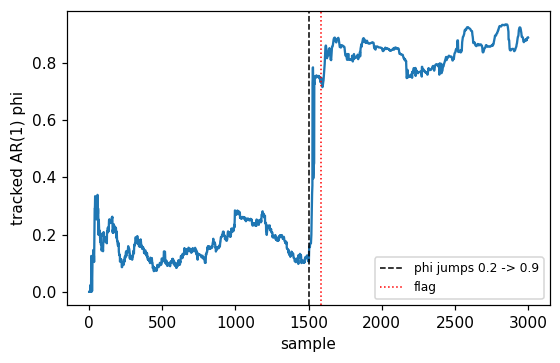

In [14]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
rng = np.random.default_rng(100)
pre, post = gen_ar1(1500, 0.2, rng), gen_ar1(1500, 0.9, rng)
f = StochasticFilter()
phis = []
for x in np.concatenate([pre, post]):
    f.update(x)
    phis.append(f.params_["ar1_phi"])
ax.plot(phis)
ax.axvline(pre.size, color="k", linestyle="--", linewidth=1, label="phi jumps 0.2 -> 0.9")
if f.last_flag_ is not None:
    ax.axvline(f.last_flag_, color="r", linestyle=":", linewidth=1, label="flag")
ax.set_xlabel("sample")
ax.set_ylabel("tracked AR(1) phi")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()

In [15]:
cost_ratio = max(us_short, us_long) / min(us_short, us_long)
print(f"cost ratio between 1,000 and 100,000 samples: {cost_ratio:.2f}x")
flag_bytes_short = len(f_short.flag_times_) * 8
flag_bytes_long = len(f_long.flag_times_) * 8
state_cap = (online_filter.state_bytes_at_1000.iloc[0] - flag_bytes_short
            + 512 * 8)
print(f"state cap {state_cap} B; switching stream tripped "
      f"{f_switch.n_flags_} flags, kept {len(f_switch.flag_times_)}, "
      f"state {state_size(f_switch)} B")
# fails if the tracker mistracks any of the three persistence levels
assert (online_tracking.tracking_mae < 0.05).all()
# fails if either kind of break is missed most of the time
assert online_filter.persistence_jump_hit_rate.iloc[0] >= 0.75
assert online_filter.volatility_switch_hit_rate.iloc[0] >= 0.75
# fails if the most favourable stationary stream (white noise) trips more
# than two flags in 3,000 samples
assert online_filter.max_false_alarms_per_3000.iloc[0] <= 2
# fails if persistence stops raising the false-alarm rate, the thing the
# white-noise-only number above hides
fa = false_alarm_rates.set_index("process").mean_flags
assert fa["AR(1) phi=0.9"] > fa["AR(1) phi=0.5"] > fa["white noise"]
# fails if the state grows past the flag deque's fixed 512-entry cap, at
# either stream length
assert online_filter.state_bytes_at_1000.iloc[0] <= state_cap
assert online_filter.state_bytes_at_100000.iloc[0] <= state_cap
# fails if the switching stream stops tripping more flags than the deque
# holds, which is what puts the cap itself under test rather than a state
# that never approaches it
assert (online_filter.flags_tripped_switching.iloc[0]
        > online_filter.flags_kept_switching.iloc[0])
# fails if the flag deque stops dropping its oldest entry (filter.py's
# deque(maxlen=512) built without the bound): the saturated state would
# then carry one entry per flag tripped and pass the cap
assert online_filter.state_bytes_switching.iloc[0] == state_cap
# fails if the byte gap between the two lengths is not entirely the flag
# deque (the one part of the state that is not fixed-size by construction)
assert (online_filter.state_bytes_at_100000.iloc[0]
        - online_filter.state_bytes_at_1000.iloc[0]
        == flag_bytes_long - flag_bytes_short)
# fails if the per-sample cost is not roughly flat with the stream length
assert cost_ratio < 1.5
if not QUICK:
    notebook.save_table("23_stochastic_image", "online_filter", online_filter)
    notebook.save_table("23_stochastic_image", "false_alarm_rates",
                        false_alarm_rates)


cost ratio between 1,000 and 100,000 samples: 1.03x
state cap 4736 B; switching stream tripped 1286 flags, kept 512, state 4736 B


Tracking error stays under 0.05 in phi at every persistence level tried
(the check above bounds it in absolute terms); as a share of `phi_true`
itself the three levels differ, largest at the weakest persistence -- the
table's `tracking_mae_pct_of_phi` column carries the actual numbers, not a
single "under 5 percent" line for all three. Both kinds of break are
caught within a few dozen samples. The false-alarm count is rare only on
the most favourable stationary stream: white noise trips at most one flag
in 3,000 samples across 30 independent draws, but the mean count rises
with persistence, and a persistent AR(1) at `phi=0.9` -- a stationary
stream by construction, and one of the three persistence levels the
tracking table above already carries -- flags far more often; the
false-alarm table shows all three levels, not white noise alone. The
state is bounded, not literally identical at 1,000 and at 100,000 samples:
the five fixed-size arrays and the sample buffer are the same size either
way, but the flag-times deque holds one entry per flag up to its own
512-entry cap, so a longer, noisier stream that has tripped more flags
carries a larger, still-bounded, state. A stream whose volatility
switches every 100 samples trips 1,286 flags over 400,000 samples and
keeps the last 512 of them, which leaves its state at the 4,736-byte cap
itself, where the two AR(1) streams sit at 640 and 2,016 bytes: the bound
is measured where it binds. The per-sample cost is the same to
within a few percent at both lengths: the filter's memory is capped and
its time does not grow with the stream, which is the whole of what makes
it a streaming method.


## 7. The generator: fit, simulate, refit

For each of six regimes: fit a generated series, simulate a fresh
realization from the fitted model, and refit the simulation. The claim is
that the round trip lands back on the same regime. A separate Student-t
simulation checks that the fat-tailed innovation reads fatter.

In [16]:
regimes = [
    ("mean-reverting", "mean-reverting", lambda rng: gen_ar1(1500, 0.7, rng)),
    ("long-memory", "long-memory", lambda rng: gen_arfima(4096, 0.3, rng)),
    ("vol-clustering", "vol-clustering",
     lambda rng: gen_garch(4000, 0.05, 0.08, 0.90, rng)),
    ("cyclical", "cyclical", lambda rng: gen_ar2_cycle(1500, 16.0, 0.97, rng)),
    ("trend+cycle", "trend+cycle",
     lambda rng: gen_trend_cycle(600, 0.02, 50.0, 3.0, 1.0, rng)[1]),
    ("white noise", "white noise", lambda rng: rng.standard_normal(1500)),
]

rows = []
for label, expected, gen in regimes:
    for seed in range(SEEDS):
        rng = np.random.default_rng(seed)
        y = gen(rng)
        m = fit_stochastic(y)
        sim = m.simulate(seed=1000 + seed)
        m2 = fit_stochastic(sim)
        rows.append(dict(regime=label, seed=seed, fitted_regime=m.regime,
                          refit_regime=m2.regime,
                          recovered=regime_matches(m2, expected)))
roundtrip = pd.DataFrame(rows)
recovery = roundtrip.groupby("regime").recovered.mean()
recovery

regime
cyclical          1.0
long-memory       1.0
mean-reverting    1.0
trend+cycle       1.0
vol-clustering    1.0
white noise       1.0
Name: recovered, dtype: float64

In [17]:
rng = np.random.default_rng(1)
y = gen_ar1(3000, 0.6, rng)
m = fit_stochastic(y)
sim_normal = m.simulate(n=5000, seed=1, dist="normal")
sim_t = m.simulate(n=5000, seed=1, dist="t", df=5.0)
kurt_normal, kurt_t = float(kurtosis(sim_normal)), float(kurtosis(sim_t))
print(f"excess kurtosis: normal {kurt_normal:.2f}, Student-t (df=5) {kurt_t:.2f}, "
      f"std {sim_normal.std():.3f} vs {sim_t.std():.3f}")
# fails if any regime's round trip lands elsewhere more than occasionally
assert (recovery >= 0.80).all()
# fails if the Student-t path is not visibly fatter-tailed at matched scale
assert kurt_t > 1.5
assert kurt_normal < 0.5
if not QUICK:
    notebook.save_table("23_stochastic_image", "roundtrip", roundtrip)

excess kurtosis: normal 0.13, Student-t (df=5) 3.35, std 1.251 vs 1.266


Every one of the six regimes round-trips at this seed count: fitting
a simulated path of the detected regime recovers that same regime every
time. The Student-t simulation carries visibly fatter tails (excess
kurtosis above the Gaussian path's by a wide margin) at essentially the
same standard deviation, the fat-tailed innovation `dist="t"` exists for.

## 8. What the router cannot do

No falsifier, no check cell: this section reports the router's own known
limits rather than testing a claim. The cycle gate's effect-size floor
(`strength > 0.08`, plus the period falling in a plausible range) is
calibrated against a white-noise null; stacking Fisher's g critical value
on top brings the white-noise false-positive rate down close to the
nominal 5 percent, but buys far less on autocorrelated (red) noise, where
Fisher's g test itself assumes a white spectrum.

In [18]:
def fisher_g_crit(n, alpha=0.05):
    m = max(int(n) // 2, 2)
    return float(1.0 - (alpha / m) ** (1.0 / (m - 1)))


CYCLE_STRENGTH, MIN_CYCLES = 0.08, 2.5


def cycle_gate_opens(y, n, *, with_fisher_g):
    seas = SecondOrderImage.of(y).seasonal(max_harmonics=4)
    s, per = seas["strength"], seas["period"]
    floor = s > CYCLE_STRENGTH
    if with_fisher_g:
        floor = floor and s > fisher_g_crit(n)
    return bool(floor and np.isfinite(per) and 4 <= per <= n / MIN_CYCLES)


rows = []
for n in (60, 88, 120, 200, 309):
    floor_hits = fisher_hits = 0
    for seed in range(CALIB_DRAWS):
        rng = np.random.default_rng(10_000 * n + seed)
        y = rng.standard_normal(n)
        floor_hits += cycle_gate_opens(y, n, with_fisher_g=False)
        fisher_hits += cycle_gate_opens(y, n, with_fisher_g=True)
    rows.append(dict(process="white noise", n=n,
                      floor_only=floor_hits / CALIB_DRAWS,
                      floor_and_fisher_g=fisher_hits / CALIB_DRAWS))

for n in (88, 200):
    floor_hits = fisher_hits = 0
    for seed in range(CALIB_DRAWS):
        rng = np.random.default_rng(20_000 * n + seed)
        y = gen_ar1(n, 0.5, rng)
        floor_hits += cycle_gate_opens(y, n, with_fisher_g=False)
        fisher_hits += cycle_gate_opens(y, n, with_fisher_g=True)
    rows.append(dict(process="AR(1) phi=0.5", n=n,
                      floor_only=floor_hits / CALIB_DRAWS,
                      floor_and_fisher_g=fisher_hits / CALIB_DRAWS))

cycle_gate_calibration = pd.DataFrame(rows)
cycle_gate_calibration

,process,n,floor_only,floor_and_fisher_g
0,white noise,60,0.465,0.080
1,white noise,88,0.440,0.090
2,white noise,120,0.305,0.075
3,white noise,200,0.060,0.060
4,white noise,309,0.000,0.000
5,AR(1) phi=0.5,88,0.910,0.650
6,AR(1) phi=0.5,200,0.725,0.725


In [19]:
# dtfit.stochastic.gates sets these two where it routes
PRE_CYCLICAL_STRENGTH, SEL_MARGIN = 0.12, 1.15
print(f"gate constants: cycle strength floor {CYCLE_STRENGTH}, minimum "
      f"cycles {MIN_CYCLES}, unit-root exemption at strength "
      f"{PRE_CYCLICAL_STRENGTH}, forecaster sel_margin {SEL_MARGIN}")
if not QUICK:
    notebook.save_table("23_stochastic_image", "cycle_gate_calibration",
                        cycle_gate_calibration)
print("no assertion below: this section reports a limit, it does not test a claim")

gate constants: cycle strength floor 0.08, minimum cycles 2.5, unit-root exemption at strength 0.12, forecaster sel_margin 1.15
no assertion below: this section reports a limit, it does not test a claim


On white noise the floor alone opens the cycle gate on close to half
the draws at record lengths of a hundred or so, and stacking Fisher's g
critical value on top brings that down to 9 percent of the draws or less at
every length tried, against the 5 percent the test is nominally sized for.
On AR(1) with phi = 0.5 the floor alone opens on 91 percent of the draws at
n = 88 and 72.5 percent at n = 200; the Fisher-g guard leaves 65 percent of
them at n = 88 and changes nothing at all at n = 200: red noise is exactly
the case Fisher's g test does not cover, since it assumes a white-noise
null. Two more constants are hand-set rather than derived, both printed
above: `pre_cyclical` exempts a series from the unit-root branch at a
strength of 0.12, and the forecaster selector's `sel_margin` lets a
structured candidate win its own backtest while trailing the random walk
there by up to 15 percent (`sel_margin` 1.15), a looser margin than the
tier's own test suite allows the merged forecast on the real series
(`packages/dtfit-experimental/tests/test_stochastic.py`). Neither constant
is touched here.

## Findings and limits

The image merges exactly once the scale budget is pinned, whether through
`SecondOrderStream`'s default eight equal blocks or through its
fold-to-coarse path, and differs only in the read-out (aggregated-variance
Hurst) that depends on the budget when it is not pinned. Recovery by route
is not one word for all six functionals: mean reversion and volatility
persistence sit at parity with their foreign route, the trend slope is the
same least-squares line computed twice rather than a comparison, the two
cycle-period rows are decided by whether the true period lands on a
periodogram bin (exactly on one at 600 samples and period 50, where the
foreign route is exact; off it at 1500 samples and period 16, where dtfit
wins), and the two Hurst functionals (one estimator under two call
spellings, not two routes) trail R/S and DFA. The 56-case regime router
ties its classical twin overall (96.4 percent each), with the same one miss in common (an
AR(2) cycle read as mean-reverting) and each side missing a different case
besides; neither side is uniformly ahead. On forecasting the picture is
mixed rather than a sweep: the merged model clearly wins on trend+cycle,
tracks the classical twin to within 0.005 percent on the mean-reverting
case (whether that tied pair beats the random walk itself flips across
seeds), and loses clearly on the AR(2) cycle and on GARCH(1,1), where both
routes read the same regime and the textbook forecaster that regime
selects -- a periodogram seasonal fit, a constant training mean -- beats
the one the merged model falls back to. The finite-order AR veto is
exercised, not just asserted: the persistent AR(1) draws' own pre-veto
Hurst statistic clears the long-memory threshold, and the router still
never routes them as long memory, while differencing a long-memory series
at its own routed d whitens it. The
streaming filter tracks, flags, and holds state bounded by a fixed cap
(the flag-times deque, not the five statistic arrays, is what a longer,
noisier stream grows) at flat per-sample cost. The generator round-trips
at every regime tried and gives Student-t innovations visibly fatter
tails than Gaussian ones.

Limits: every process here is synthetic; the real gallery is notebook
36's. Every number above is one machine, one Python process. The retired
`method="lsi"` / `method="eac"` spelling of `dtfit.stochastic`'s own
estimators appears in this notebook only inside a call, never in a label
or a table column, and aligning it with the rest of the core's
`basis="legendre"` / `"block"` naming is left open, not fixed here. The
cycle gate's white-noise-only calibration and its two hand-set constants
are section 8's own finding, not fixed here.


In [20]:
print(notebook.provenance(STARTED))

2026-09-21 commit bbdb713 dtfit 0.4.0 dtfit-experimental 0.1.0 25.6s
